In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cv2 
import os 
import torch

import numpy as np

BEDLAM_PATH = "/scratch/cq244/BEDLAM/data/"
CKPT_PATH = "/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt"
PATH = "/scratch/cq244/BEDLAM/data/training_labels/all_npz_12_training_extra_mhr/20221013_3_250_batch01hand_orbit_bigOffice_6fps.npz"


device = "cuda" if torch.cuda.is_available() else "cpu"


FPS sampled 256 points out of 18439 vertices.


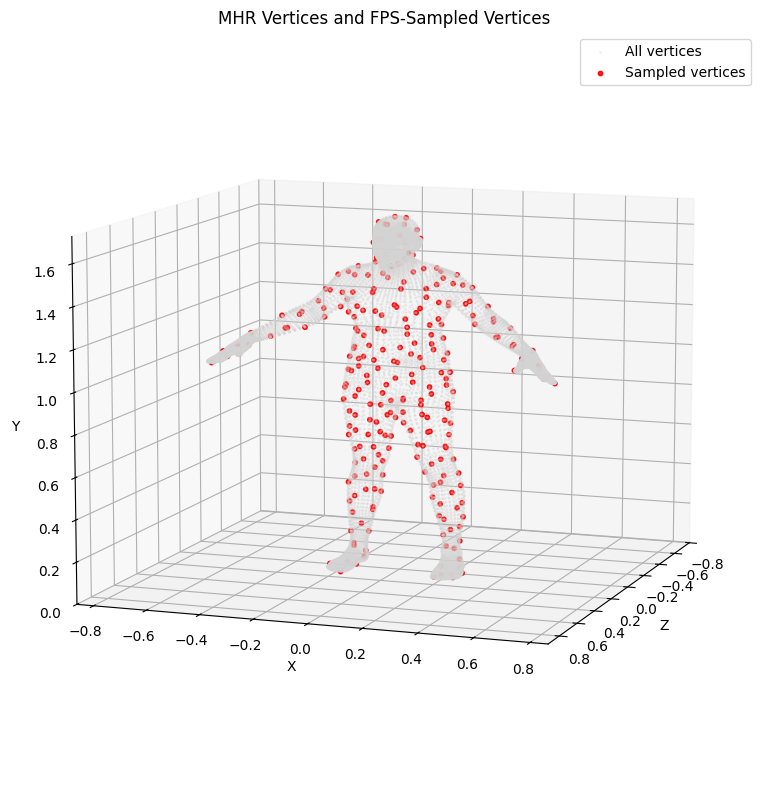

In [3]:

data = np.load(PATH)
index = 100


mhr_model = torch.jit.load(
    "/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt",
    map_location=device,
).to(device)


neutral_inputs ={
    'identity_coeffs': torch.zeros_like(torch.from_numpy(data['identity_coeffs'][[index]])).to(device),
    'model_parameters': torch.zeros_like(torch.from_numpy(data['lbs_model_params'][[index]])).to(device),
    'face_expr_coeffs': torch.zeros_like(torch.from_numpy(data['face_expr_coeffs'][[index]])).to(device),
}

mhr_output = mhr_model(
    **neutral_inputs,
    apply_correctives=True,
)
mhr_verts, mhr_skeleton_state = mhr_output # 127, 8
mhr_j3d = mhr_skeleton_state[..., :3] 
mhr_verts /= 100.0
mhr_j3d /= 100.0

# Farthest Point Sampling (FPS) to sample n points from mhr_verts
# mhr_verts has shape [1, N, 3]
N = mhr_verts.shape[1]
num_samples = 256  # choose desired number of sampled points (<= N)
num_samples = min(num_samples, N)

# Simple FPS implementation for a single batch element
def farthest_point_sampling(points, n_samples):
    """points: [N, 3], returns indices [n_samples] of sampled points."""
    device = points.device
    N = points.shape[0]
    # Initialize array of distances to large value
    distances = torch.full((N,), float('inf'), device=device)
    # Start from a random point
    farthest_idx = torch.randint(0, N, (1,), device=device).item()
    sampled_indices = []
    for _ in range(n_samples):
        sampled_indices.append(farthest_idx)
        # Compute squared distances to the newly selected point
        current_point = points[farthest_idx].unsqueeze(0)  # [1, 3]
        dist = torch.sum((points - current_point) ** 2, dim=1)  # [N]
        # Update minimum distances
        distances = torch.minimum(distances, dist)
        # Select next farthest point
        farthest_idx = torch.argmax(distances).item()
    return torch.tensor(sampled_indices, device=device, dtype=torch.long)

# Apply FPS on the neutral-pose vertices (first batch element)
points = mhr_verts[0]  # [N, 3]
sampled_indices = farthest_point_sampling(points, num_samples)
sampled_points = points[sampled_indices]  # [num_samples, 3]

print(f"FPS sampled {num_samples} points out of {N} vertices.")

# Visualize full vertices and sampled vertices in 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

full_points = points.detach().cpu().numpy()        # [N, 3]
sampled_points_np = sampled_points.detach().cpu().numpy()  # [num_samples, 3]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot full vertex cloud (light color)
ax.scatter(full_points[:, 0], full_points[:, 1], full_points[:, 2],
           c='lightgray', s=1, alpha=0.3, label='All vertices')

# Plot sampled points (highlighted)
ax.scatter(sampled_points_np[:, 0], sampled_points_np[:, 1], sampled_points_np[:, 2],
           c='red', s=10, alpha=0.9, label='Sampled vertices')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('MHR Vertices and FPS-Sampled Vertices')
ax.legend()

# Set equal aspect for 3D
xyz_min = full_points.min(axis=0)
xyz_max = full_points.max(axis=0)
xyz_center = (xyz_min + xyz_max) / 2.0
xyz_range = (xyz_max - xyz_min).max() / 2.0
ax.set_xlim([xyz_center[0] - xyz_range, xyz_center[0] + xyz_range])
ax.set_ylim([xyz_center[1] - xyz_range, xyz_center[1] + xyz_range])
ax.set_zlim([xyz_center[2] - xyz_range, xyz_center[2] + xyz_range])

ax.view_init(elev=10, azim=20, vertical_axis="y")

plt.tight_layout()
plt.show()




Total vertices: 18439, positive side: 9190, negative side: 9249
Sampling 64 points from the positive half-mesh.
Half-mesh samples: 64, symmetric union size: 128


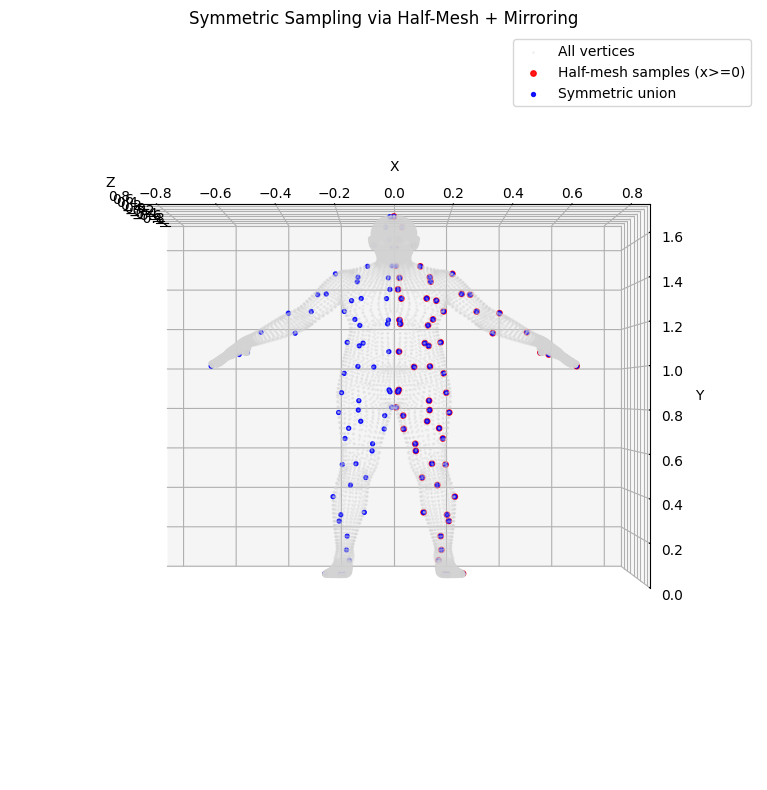

Saved sampled indices to: mhr_kp_sample_128.npy


In [6]:
# Symmetric sampling via half-mesh strategy
# 1) Build a half-mesh (x >= 0)
# 2) Run FPS on that half
# 3) For each sampled point, find a corresponding vertex in the other half (x < 0)

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Use the vertices from the neutral pose
points_full = mhr_verts[0]  # [N, 3]
N_full = points_full.shape[0]

# Split into two halves wrt x-axis
x_coords = points_full[:, 0]
mask_pos = x_coords >= 0.0  # "right" or non-negative side
mask_neg = x_coords < 0.0   # "left" side

pos_indices_all = torch.nonzero(mask_pos, as_tuple=False).squeeze(1)
neg_indices_all = torch.nonzero(mask_neg, as_tuple=False).squeeze(1)

pos_points = points_full[pos_indices_all]  # [N_pos, 3]
neg_points = points_full[neg_indices_all]  # [N_neg, 3]

print(f"Total vertices: {N_full}, positive side: {pos_points.shape[0]}, negative side: {neg_points.shape[0]}")

# Number of samples per half (reuse num_samples from previous cell if defined)
base_num_samples = 128

num_half_samples = min(base_num_samples // 2, pos_points.shape[0])
print(f"Sampling {num_half_samples} points from the positive half-mesh.")

# Run FPS on the positive half (using the function from the previous cell)
half_sample_local = farthest_point_sampling(pos_points, num_half_samples)   # indices in pos_points
half_sample_global = pos_indices_all[half_sample_local]                     # indices in full mesh
half_sample_points = points_full[half_sample_global]                        # [num_half_samples, 3]

# For each sampled point on the positive side, find a matching vertex on the negative side
with torch.no_grad():
    # Mirror the sampled positive points across x-axis
    target_mirrored = half_sample_points.clone()
    target_mirrored[:, 0] *= -1.0

    # Compute pairwise squared distances to negative-side vertices
    # Using: ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    a2 = (target_mirrored ** 2).sum(dim=1, keepdim=True)         # [num_half_samples, 1]
    b2 = (neg_points ** 2).sum(dim=1, keepdim=True).T            # [1, N_neg]
    ab = target_mirrored @ neg_points.T                          # [num_half_samples, N_neg]
    dists2 = a2 + b2 - 2.0 * ab                                  # [num_half_samples, N_neg]

    sym_local_neg = torch.argmin(dists2, dim=1)                  # [num_half_samples]
    sym_global_neg = neg_indices_all[sym_local_neg]              # [num_half_samples]

# Union of positive samples and their symmetric partners on the negative side
all_sym_indices = torch.cat([half_sample_global, sym_global_neg], dim=0)
all_sym_indices = torch.unique(all_sym_indices)                  # sorted unique

symmetric_points = points_full[all_sym_indices]                  # [M, 3]
print(f"Half-mesh samples: {len(half_sample_global)}, symmetric union size: {len(all_sym_indices)}")

# Visualize: full mesh, positive-half samples, and symmetric partners
full_np = points_full.detach().cpu().numpy()                     # [N, 3]
half_np = half_sample_points.detach().cpu().numpy()              # [num_half_samples, 3]
syms_np = symmetric_points.detach().cpu().numpy()                # [M, 3]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# All vertices
ax.scatter(full_np[:, 0], full_np[:, 1], full_np[:, 2],
           c='lightgray', s=1, alpha=0.25, label='All vertices')

# Positive-half FPS samples
ax.scatter(half_np[:, 0], half_np[:, 1], half_np[:, 2],
           c='red', s=15, alpha=0.9, label='Half-mesh samples (x>=0)')

# Symmetric union (both sides)
ax.scatter(syms_np[:, 0], syms_np[:, 1], syms_np[:, 2],
           c='blue', s=8, alpha=0.9, label='Symmetric union')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Symmetric Sampling via Half-Mesh + Mirroring')
ax.legend()

# Equal aspect ratio
xyz_min = full_np.min(axis=0)
xyz_max = full_np.max(axis=0)
xyz_center = (xyz_min + xyz_max) / 2.0
xyz_range = (xyz_max - xyz_min).max() / 2.0
ax.set_xlim([xyz_center[0] - xyz_range, xyz_center[0] + xyz_range])
ax.set_ylim([xyz_center[1] - xyz_range, xyz_center[1] + xyz_range])
ax.set_zlim([xyz_center[2] - xyz_range, xyz_center[2] + xyz_range])

ax.view_init(elev=0, azim=0, vertical_axis="y")

plt.tight_layout()
plt.show()



# Save the FPS-sampled indices to disk for future use
import numpy as np

save_path = f"mhr_kp_sample_{base_num_samples}.npy"
np.save(save_path, all_sym_indices.detach().cpu().numpy())
print(f"Saved sampled indices to: {save_path}")




In [ ]:
indices = np.load("/scratch/cq244/sam-3d-body/tinker/mhr_kp_sample_128.npy")

print(indices)
print(indices.shape)

[  746   939  2346  2366  2380  2811  3632  3825  4879  5232  5252  5266
  5796  5810  5818  5828  5836  5840  5861  5866  5871  5882  6072  6201
  6217  6342  6353  6389  6399  6463  6523  6529  6587  6605  6644  6670
  6748  6881  6921  6938  6943  6948  6969  6973  6981  6991  6999  7013
  7139  7221  7318  7334  7416  7427  7538  7602  7612  7640  7698  7704
  7752  7823  7854  7939  8056  8062  8129  8213  8380  8453  8624  9061
 10728 11227 11277 11281 11296 11316 11335 11376 11407 11421 11472 11490
 11605 11684 11697 11774 11881 11897 11947 12034 12142 12260 12574 12734
 13226 13300 13379 13526 13635 13808 14220 14793 15787 16436 16440 16471
 16501 16507 16541 16587 16600 16636 16676 16748 16848 16861 16961 17064
 17080 17126 17215 17304 17437 17754 17927 18421]
(128,)


: 